## Setup and dependencies
Please use this section to list and set up all your required libraries/dependencies and your plotting environment.

In [40]:
pip install scikeras[tensorflow]

In [ ]:
pip install medmnist

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import time
import pandas as pd
import itertools
import random
import tensorflow as tf

import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from torch.utils.data import DataLoader
from collections import Counter
from tensorflow import keras
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV,train_test_split
#from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from scikeras.wrappers import KerasClassifier
from scipy.stats import randint as sp_randint
from scipy.stats import uniform
from IPython.display import display, clear_output
from sklearn.metrics import accuracy_score
from scipy import ndimage
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
random.seed(42)

## 1. Data loading, exploration, and preprocessing


Code to load the dataset is provided in the following cell. Please proceed with your data exploration and preprocessing in the remainder of this section.

In [ ]:
import medmnist
from medmnist import OrganAMNIST
print("Loading MedMNIST-OrganAMNIST dataset...")

train_data = OrganAMNIST(split='train', download=True, size=28)
test_data = OrganAMNIST(split='test', download=True, size=28)

X_train = train_data.imgs
y_train = train_data.labels.squeeze()
X_test = test_data.imgs
y_test = test_data.labels.squeeze()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

train_class_distribution = Counter(y_train)
test_class_distribution = Counter(y_test)
print("\ntrain class distribution:", train_class_distribution)
print("test class distribution:", test_class_distribution)

num_classes = 11

Loading MedMNIST-OrganAMNIST dataset...
X_train shape: (34561, 28, 28)
y_train shape: (34561,)
X_test shape: (17778, 28, 28)
y_test shape: (17778,)

train class distribution: Counter({np.uint8(6): 6164, np.uint8(4): 3963, np.uint8(8): 3929, np.uint8(7): 3919, np.uint8(5): 3817, np.uint8(10): 3561, np.uint8(9): 3031, np.uint8(0): 1956, np.uint8(3): 1474, np.uint8(1): 1390, np.uint8(2): 1357})
test class distribution: Counter({np.uint8(6): 3285, np.uint8(4): 2064, np.uint8(5): 1965, np.uint8(10): 1884, np.uint8(8): 1813, np.uint8(7): 1747, np.uint8(9): 1622, np.uint8(0): 1036, np.uint8(2): 793, np.uint8(3): 785, np.uint8(1): 784})


In [ ]:
# Count the number of occurrences of each class in the datasets
train_class_distribution = Counter(y_train)
test_class_distribution = Counter(y_test)

print("Training class distribution:", {int(k): v for k, v in train_class_distribution.items()})
print("Testing class distribution:", {int(k): v for k, v in test_class_distribution.items()})

Training class distribution: {6: 6164, 8: 3929, 5: 3817, 9: 3031, 7: 3919, 4: 3963, 0: 1956, 10: 3561, 3: 1474, 2: 1357, 1: 1390}
Testing class distribution: {4: 2064, 0: 1036, 8: 1813, 6: 3285, 5: 1965, 7: 1747, 10: 1884, 2: 793, 9: 1622, 1: 784, 3: 785}


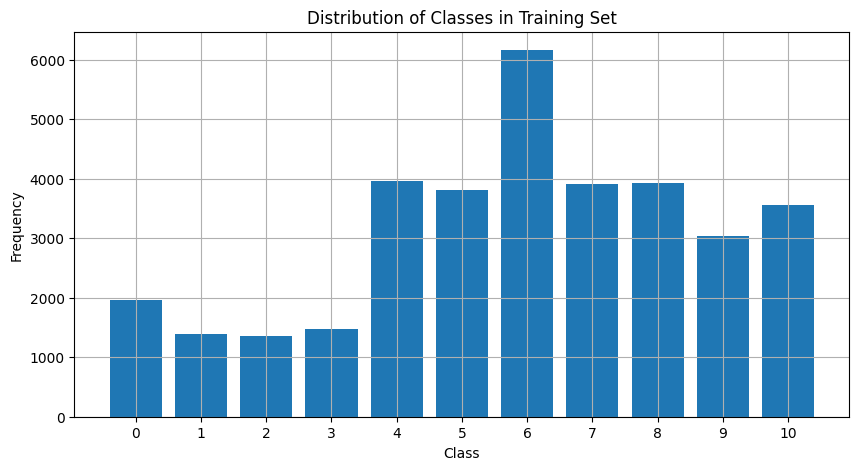

In [ ]:
# Calculate the number of classes
num_classes = len(np.unique(y_train))

plt.figure(figsize=(10, 5))
plt.hist(y_train, bins=np.arange(num_classes + 1) - 0.5, rwidth=0.8)
plt.title('Distribution of Classes in Training Set')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(np.arange(num_classes))
plt.xticks(np.arange(num_classes), [str(i) for i in range(num_classes)])
plt.grid(True)
plt.show()

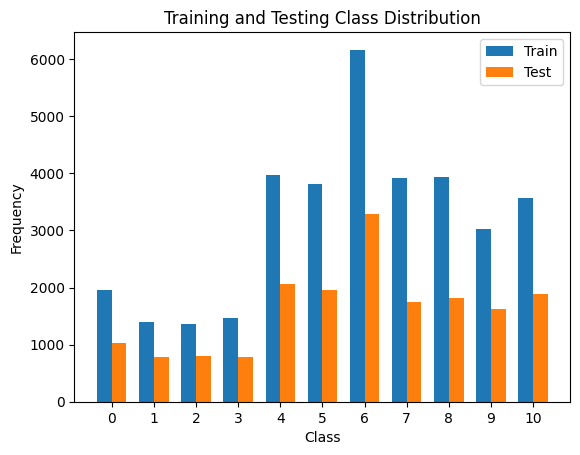

In [ ]:
# Sorting keys for consistent plotting
all_classes = sorted(set(train_class_distribution.keys()).union(set(test_class_distribution.keys())))
train_counts = [train_class_distribution.get(cls, 0) for cls in all_classes]
test_counts = [test_class_distribution.get(cls, 0) for cls in all_classes]

# Plotting the distributions
fig, ax = plt.subplots()
bar_width = 0.35
index = np.arange(len(all_classes))

bar1 = ax.bar(index, train_counts, bar_width, label='Train')
bar2 = ax.bar(index + bar_width, test_counts, bar_width, label='Test')

ax.set_xlabel('Class')
ax.set_ylabel('Frequency')
ax.set_title('Training and Testing Class Distribution')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(all_classes)
ax.legend()

plt.show()

In [ ]:
def is_centered(image):
    # Calculate the center coordinates of the image
    center_X = image.shape[1] // 2
    center_y = image.shape[0] // 2
    # Check if the image is centered
    return center_X == image.shape[1] // 2 and center_y == image.shape[0] // 2

centered_images = []
# Loop through each image in X_train
for img in X_train:
    # Check if the image is centered
    if is_centered(img):
        # If centered, add it to the list of centered images
        centered_images.append(img)

num_centered = len(centered_images)
total_images = len(X_train)
# Calculate the percentage of centered images
percentage_centered = (num_centered / total_images) * 100

# Print the results
print(f"The total number of pictures: {total_images}, Number of pictures in the center: {num_centered}")
print(f"Center image ratio: {percentage_centered:.2f}%")


The total number of pictures: 34561, Number of pictures in the center: 34561
Center image ratio: 100.00%


In [ ]:
def average_pixel_intensity(X, y):
    # Dictionary to store average pixel intensities per class
    averages = {}

    # Iterate over unique classes in y
    for cls in np.unique(y):
        # Get the indices of samples belonging to the current class
        idxs = np.where(y == cls)[0]
        # Extract images of the current class
        class_images = X[idxs]
        # Calculate the average pixel intensity for the class
        average_intensity = class_images.mean()
        # Store the average intensity for the class in the dictionary
        averages[cls] = average_intensity

    return averages

# Calculate average pixel intensity per class for the training data
avg_intensity = average_pixel_intensity(X_train, y_train)
print("Average pixel intensity per class:", avg_intensity)


Average pixel intensity per class: {np.uint8(0): np.float64(109.90084407996328), np.uint8(1): np.float64(182.40020554984585), np.uint8(2): np.float64(180.10987528762425), np.uint8(3): np.float64(122.12155941073851), np.uint8(4): np.float64(123.82282155860074), np.uint8(5): np.float64(134.21681367726552), np.uint8(6): np.float64(131.38446969069912), np.uint8(7): np.float64(75.76533932021393), np.uint8(8): np.float64(67.89688722269258), np.uint8(9): np.float64(134.91042812704097), np.uint8(10): np.float64(125.3484811363467)}


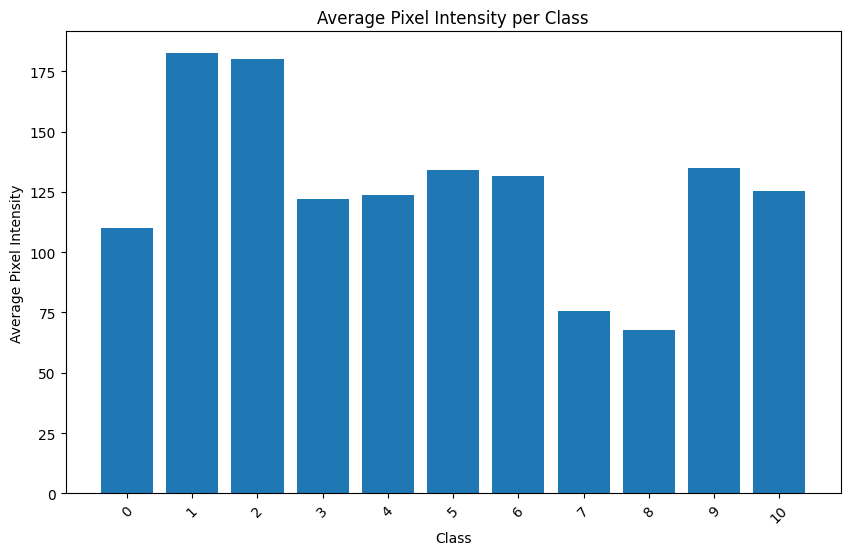

In [ ]:
avg_intensity = average_pixel_intensity(X_train, y_train)
classes = list(avg_intensity.keys())
intensities = list(avg_intensity.values())
plt.figure(figsize=(10, 6))
plt.bar(classes, intensities)
plt.xlabel('Class')
plt.ylabel('Average Pixel Intensity')
plt.title('Average Pixel Intensity per Class')
plt.xticks(classes, rotation=45)  # Rotates class labels for better visibility if needed
plt.show()

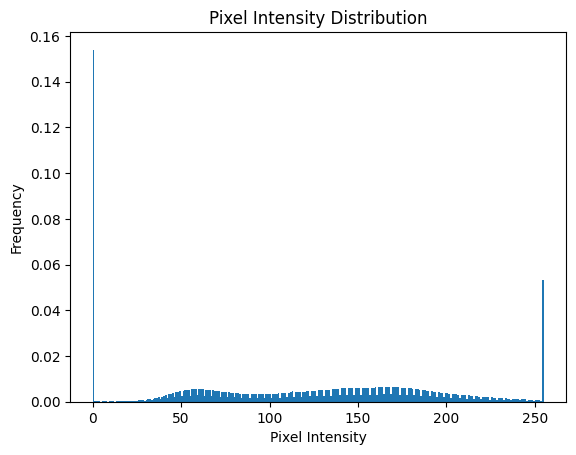

In [ ]:
# Flatten the training images to create a 1D array of pixel values
pixel_values = X_train.flatten()

# Calculate the minimum and maximum pixel values in the training data
pixel_min = np.min(pixel_values)
pixel_max = np.max(pixel_values)

# Plot a histogram of pixel intensities with 256 bins (for grayscale images)
# The range is set from the minimum to maximum pixel values
plt.hist(pixel_values, bins=256, range=(pixel_min, pixel_max), density=True)
plt.xlabel('Pixel Intensity')  # Set label for x-axis
plt.ylabel('Frequency')  # Set label for y-axis
plt.title('Pixel Intensity Distribution')  # Set title of the plot
plt.show()  # Display the histogram plot


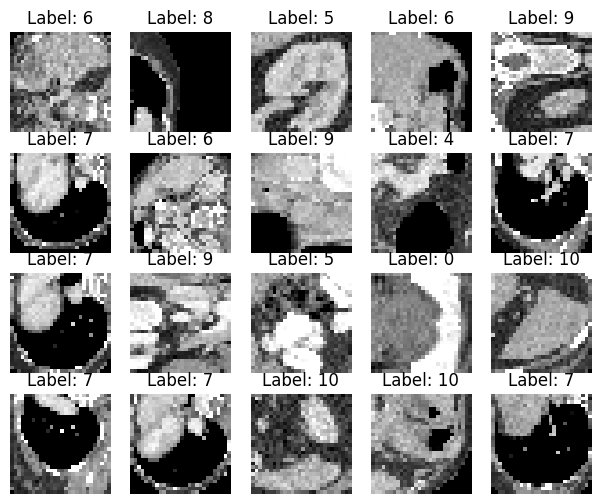

In [ ]:
# Draw an image grid
def plot_images(images, labels, rows, cols):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i], cmap='gray')
            ax.set_title(f"Label: {labels[i]}")
        ax.axis('off')
    plt.show()

# Draw a sample of 20 images from the training set
sample_images = X_train[:20]
sample_labels = y_train[:20]
plot_images(sample_images, sample_labels, 4, 5)

### Examples of preprocessed data
Please print/display some examples of your preprocessed data here.

In [ ]:
# Convert training and test data to PyTorch tensors
# Flatten images to 1D arrays (reshape to -1, 784)
X_train_tensor = torch.tensor(X_train.reshape(-1, 784), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # Convert labels to long data type
X_test_tensor = torch.tensor(X_test.reshape(-1, 784), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Print the shapes of the tensors to check dimensions
print("X_train_tensor shape:", X_train_tensor.shape)  # Print shape of X_train_tensor
print("y_train_tensor shape:", y_train_tensor.shape)  # Print shape of y_train_tensor
print("X_test_tensor shape:", X_test_tensor.shape)  # Print shape of X_test_tensor
print("y_test_tensor shape:", y_test_tensor.shape)  # Print shape of y_test_tensor


X_train_tensor shape: torch.Size([34561, 784])
y_train_tensor shape: torch.Size([34561])
X_test_tensor shape: torch.Size([17778, 784])
y_test_tensor shape: torch.Size([17778])


In [ ]:
# Reshape the training and test tensors to have a flattened representation
X_train_flat = X_train_tensor.view(X_train_tensor.shape[0], -1)
X_test_flat = X_test_tensor.view(X_test_tensor.shape[0], -1)

# Checking the unique classes in the training and test sets
# Get the unique classes from the labels (y_train and y_test)
unique_classes_train = np.unique(y_train)
unique_classes_test = np.unique(y_test)

# Print the unique classes in the training and test sets
print("Unique classes in train set:", unique_classes_train)
print("Unique classes in test set:", unique_classes_test)


Unique classes in train set: [ 0  1  2  3  4  5  6  7  8  9 10]
Unique classes in test set: [ 0  1  2  3  4  5  6  7  8  9 10]


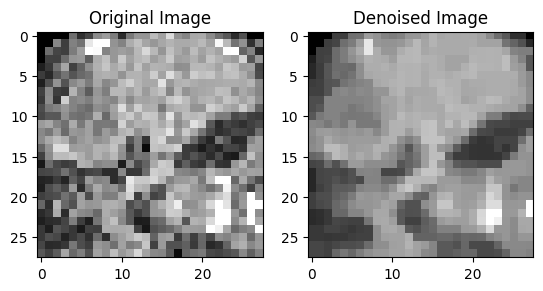

In [ ]:
# Normalize data type
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Normalize pixel values in the range [0, 1]
X_train = X_train / 255.
X_test = X_test / 255.

# Denoise the training data using median filtering
denoised_X_train = np.zeros_like(X_train)  # Initialize an array for denoised images
for i in range(len(X_train)):
    denoised_X_train[i] = ndimage.median_filter(X_train[i], size=3)  # Apply median filtering

# Plot the original and denoised images for comparison
plt.subplot(1, 2, 1)
plt.imshow(X_train[0], cmap='gray')  # Display the first original image
plt.title('Original Image')  # Set title for the subplot

plt.subplot(1, 2, 2)
plt.imshow(denoised_X_train[0], cmap='gray')  # Display the first denoised image
plt.title('Denoised Image')  # Set title for the subplot

plt.show()  # Show the plot


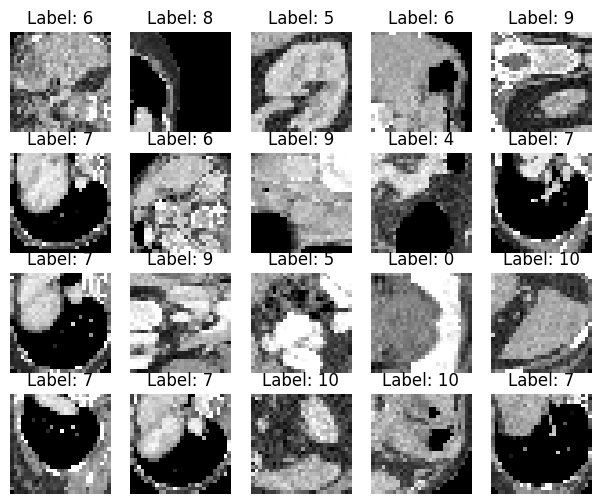

In [ ]:
#  Normalized pixel values: The pixel values are scaled from [0, 255] to [0, 1], which contributes to the training efficiency and convergence of the model.
X_train_normalized = X_train
X_test_normalized = X_test

# Display some examples of the normalized data
plot_images(X_train_normalized[:20], sample_labels, 4, 5)

## 2. Algorithm design and setup

### Algorithm of choice from first six weeks of course

In [ ]:
svm_model = SVC(random_state=0)

X_train_np02 = X_train_tensor.numpy().astype(np.float32)
y_train_np02 = y_train_tensor.numpy()
X_test_np02 = X_test_tensor.numpy().astype(np.float32)
y_test_np02 = y_test_tensor.numpy()

# Perform PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_np02.reshape(X_train_np02.shape[0], -1))
X_test_pca = pca.transform(X_test_np02.reshape(X_test_np02.shape[0], -1))

# Split data into train and validation sets
X_train_val, X_val, y_train_val, y_val = train_test_split(
    X_train_pca, y_train_np02, test_size=0.25, random_state=0)

### Fully connected neural network

In [ ]:
# Define the neural network
class MLP(nn.Module):
    def __init__(self, input_size, hidden_units_per_layer, num_classes):
        super(MLP, self).__init__()
        self.input_size = input_size # The number of input features
        self.hidden_units_per_layer = hidden_units_per_layer # A list that defines the number of neurons in each hidden layer
        self.num_classes = num_classes # The number of output classes for the network
        self.layers = nn.ModuleList([nn.Linear(input_size, hidden_units_per_layer[0])])
        for i in range(1, len(hidden_units_per_layer)): # Iterates over the indices of the hidden_units_per_layer starting from the second element
            self.layers.append(nn.Linear(hidden_units_per_layer[i - 1], hidden_units_per_layer[i])) # Each iteration adds a new layer
        self.output_layer = nn.Linear(hidden_units_per_layer[-1], num_classes) # Defines the output layer of the network
        self.relu = nn.ReLU() # Defines the ReLU activation function

    def forward(self, x):
        x = x.view(-1, self.input_size)
        for layer in self.layers:
            x = self.relu(layer(x))
        x = self.output_layer(x)
        return x

In [ ]:
def train(model, X_train, X_test, y_train, y_test, num_epochs, learning_rate):
    criterion = nn.CrossEntropyLoss() #Initializes the Cross Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate) # Sets up the Adam optimizer with the given learning rate
    train_losses = [] # store the loss values for each epoch during training and testing
    test_losses = []
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad() # Clears old gradients from the last step
        train_outputs = model(X_train)
        train_loss = criterion(train_outputs, y_train)
        train_loss.backward() # Performs backpropagation to calculate the gradients
        optimizer.step() # Updates the model parameters based on the gradients
        train_losses.append(train_loss.item()) # Records the training loss

        model.eval()
        with torch.no_grad(): # Ensures that gradients are not computed during testing
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            test_losses.append(test_loss.item())

            if (epoch + 1) % 10 == 0: # Every 10 epochs
                print(f"Epoch {epoch + 1}: Train Loss = {train_loss.item()}, Test Loss = {test_loss.item()}")

    return train_losses, test_losses

In [ ]:
# Create loss plot
def plot_loss(loss, save_path=None):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(loss, label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.legend()

In [ ]:
# Calculate confusion matrix
def plot_confusion_matrix(y_test, predicted):
    conf_matrix = confusion_matrix(y_test, predicted)
    print("Confusion Matrix:")
    print(conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 8))
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

In [ ]:
# Set the value of hyperparameter to test the model
input_size = 784
num_classes = 11
hidden_units_per_layer = [512,256]
learning_rate =  0.1
num_epoch = 50

In [ ]:
# training this model
model = MLP(input_size, hidden_units_per_layer, num_classes)
train(model, X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor, num_epoch, learning_rate)

Epoch 10: Train Loss = 262.3340759277344, Test Loss = 50.713993072509766
Epoch 20: Train Loss = 2.4124276638031006, Test Loss = 10.019440650939941
Epoch 30: Train Loss = 2.352726459503174, Test Loss = 11.31144905090332
Epoch 40: Train Loss = 2.3102474212646484, Test Loss = 11.864715576171875
Epoch 50: Train Loss = 2.2994446754455566, Test Loss = 12.096681594848633


([19.32512092590332,
  1284768.5,
  87204.5546875,
  27187.775390625,
  19931.171875,
  9062.17578125,
  2570.901611328125,
  961.9517822265625,
  579.2860107421875,
  262.3340759277344,
  44.65239715576172,
  2.52716064453125,
  2.488598346710205,
  2.4572207927703857,
  2.443894863128662,
  2.437040328979492,
  2.430508852005005,
  2.42423415184021,
  2.4182286262512207,
  2.4124276638031006,
  2.406736135482788,
  2.401057243347168,
  2.395312786102295,
  2.3894550800323486,
  2.383466958999634,
  2.3773603439331055,
  2.3711721897125244,
  2.364957809448242,
  2.3587849140167236,
  2.352726459503174,
  2.346855640411377,
  2.3412418365478516,
  2.3359456062316895,
  2.3310160636901855,
  2.326489210128784,
  2.3223891258239746,
  2.3187241554260254,
  2.31549072265625,
  2.3126728534698486,
  2.3102474212646484,
  2.308180093765259,
  2.3064351081848145,
  2.304971218109131,
  2.30374813079834,
  2.302725315093994,
  2.301865816116333,
  2.301135301589966,
  2.300503969192505,
  2.

### Convolutional neural network

In [ ]:
# Define a function to create a CNN model with dropout and specified optimizer
def create_model(dropout_rate=0.5, optimizer='adam'):
    # Define the architecture of the CNN model using Keras Sequential API
    model = keras.Sequential([
        keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(11, activation="softmax"),
    ])
    # Compile the model with sparse categorical crossentropy loss, specified optimizer, and accuracy metric
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Convert training and test tensors to NumPy arrays and reshape for CNN input
X_train_np = X_train_tensor.numpy().astype(np.float32).reshape(-1, 28, 28, 1)
y_train_np = y_train_tensor.numpy()
X_test_np = X_test_tensor.numpy().astype(np.float32).reshape(-1, 28, 28, 1)
y_test_np = y_test_tensor.numpy()

# Create a KerasClassifier with the create_model function and set verbose=0 to suppress training logs
from scikeras.wrappers import KerasClassifier
model = KerasClassifier(build_fn=create_model, verbose=0)
#model = keras.wrappers.scikit_learn.KerasClassifier(build_fn=create_model, verbose=0)


## 3. Hyperparameter tuning

### Algorithm of choice from first six weeks of course

In [ ]:

param_grid_simple = {
    'C': [1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

grid_search = GridSearchCV(
    SVC(random_state=0),
    param_grid_simple,
    cv=2,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("Start searching...")
grid_search.fit(X_train_val, y_train_val)

print("Best parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Start searching...
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Accuracy: 0.9753472222222221


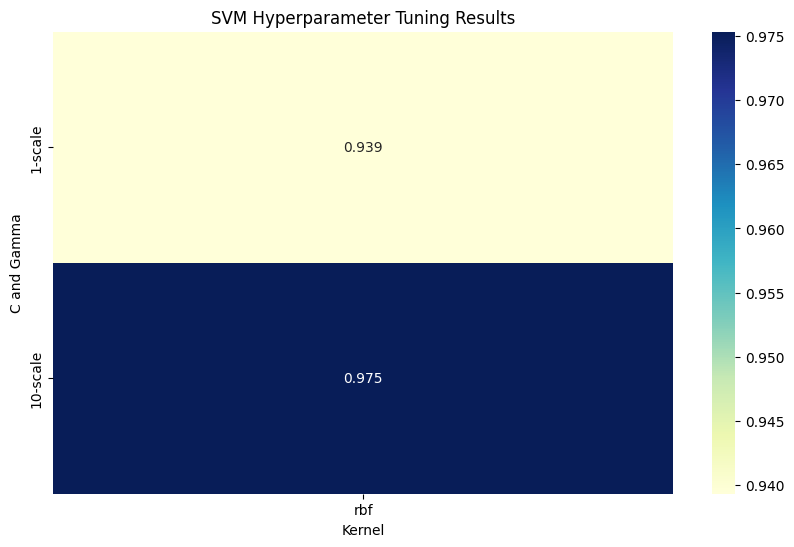

In [ ]:
# Create a DataFrame from the grid search results
results = pd.DataFrame(grid_search.cv_results_)

# Focus on the columns of interest
results_pivot = results.pivot_table(values='mean_test_score',
                                    index=['param_C', 'param_gamma'],
                                    columns='param_kernel')

plt.figure(figsize=(10, 6))
sns.heatmap(results_pivot, annot=True, cmap='YlGnBu', fmt=".3f")
plt.title('SVM Hyperparameter Tuning Results')
plt.xlabel('Kernel')
plt.ylabel('C and Gamma')
plt.show()

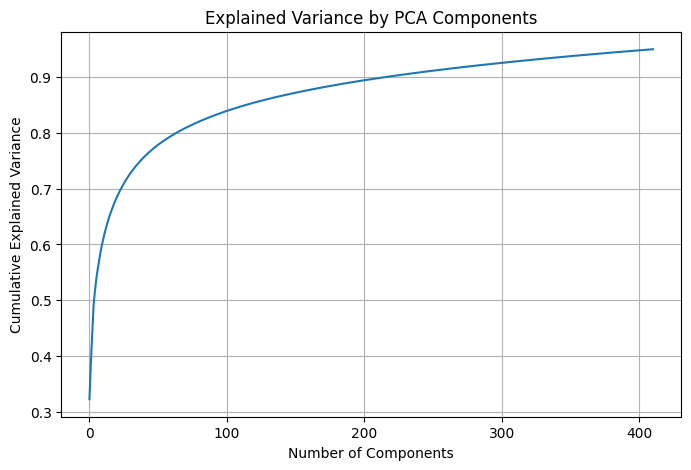

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

### Fully connected neural network

In [ ]:
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    total = labels.size(0)
    correct = (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

In [ ]:
learning_rates = [0.001, 0.01, 0.1]
hidden_units_per_layers = [[512,256], [512, 256, 128], [512, 256, 128, 64]]
num_epochs = [100,150,200]

In [ ]:
results = []
best_accuracy = 0
best_params = {}

for lr, hidden_units_per_layer, epochs in itertools.product(learning_rates, [tuple(layer) for layer in hidden_units_per_layers], num_epochs):
    start_time = time.time()  # Start time measurement

    model = MLP(input_size, hidden_units_per_layer, num_classes)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # Train the model and record training time
    train(model, X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor, epochs, lr)
    training_time = time.time() - start_time  # Calculate elapsed time

    model.eval()
    with torch.no_grad():
        outputs = model(X_train_tensor)
        current_accuracy = calculate_accuracy(outputs, y_train_tensor)

    # Save the results
    results.append({
        'learning_rate': lr,
        'hidden_units_per_layer': hidden_units_per_layer,  # This is now a tuple
        'epochs': epochs,
        'accuracy': current_accuracy,
        'runtime': training_time
    })

    # Update the best parameters if current accuracy is higher
    if current_accuracy > best_accuracy:
        best_accuracy = current_accuracy
        best_params = {'lr': lr, 'hidden_units_per_layer': hidden_units_per_layer, 'epochs': epochs}

# Print the best parameters found
print("Best params:", best_params)

Epoch 10: Train Loss = 24.474857330322266, Test Loss = 18.267498016357422
Epoch 20: Train Loss = 3.520564556121826, Test Loss = 3.6399123668670654
Epoch 30: Train Loss = 1.7420060634613037, Test Loss = 1.9374160766601562
Epoch 40: Train Loss = 1.3681929111480713, Test Loss = 1.5657455921173096
Epoch 50: Train Loss = 1.1847704648971558, Test Loss = 1.4046293497085571
Epoch 60: Train Loss = 1.0639432668685913, Test Loss = 1.301632285118103
Epoch 70: Train Loss = 0.9664466381072998, Test Loss = 1.2129935026168823
Epoch 80: Train Loss = 0.8816859722137451, Test Loss = 1.1581705808639526
Epoch 90: Train Loss = 0.8163599967956543, Test Loss = 1.1180444955825806
Epoch 100: Train Loss = 0.7658712267875671, Test Loss = 1.0897773504257202
Epoch 10: Train Loss = 54.91542434692383, Test Loss = 46.20249938964844
Epoch 20: Train Loss = 6.132528781890869, Test Loss = 4.753478050231934
Epoch 30: Train Loss = 2.2674202919006348, Test Loss = 2.2844905853271484
Epoch 40: Train Loss = 1.4893569946289062, 

In [36]:
df = pd.DataFrame(results)
print(df)

    learning_rate hidden_units_per_layer  epochs   accuracy     runtime
0           0.001             (512, 256)     100  73.053442  119.871987
1           0.001             (512, 256)     150  76.213073  184.616922
2           0.001             (512, 256)     200  81.325772  252.693475
3           0.001        (512, 256, 128)     100  70.941234  130.625852
4           0.001        (512, 256, 128)     150  79.158589  197.173053
5           0.001        (512, 256, 128)     200  86.994011  257.775164
6           0.001    (512, 256, 128, 64)     100  63.270739  133.514477
7           0.001    (512, 256, 128, 64)     150  79.711235  194.453075
8           0.001    (512, 256, 128, 64)     200  84.277075  263.809440
9           0.010             (512, 256)     100  39.478024  126.355264
10          0.010             (512, 256)     150  40.276612  178.716161
11          0.010             (512, 256)     200  17.881427  240.040773
12          0.010        (512, 256, 128)     100  64.057753  129

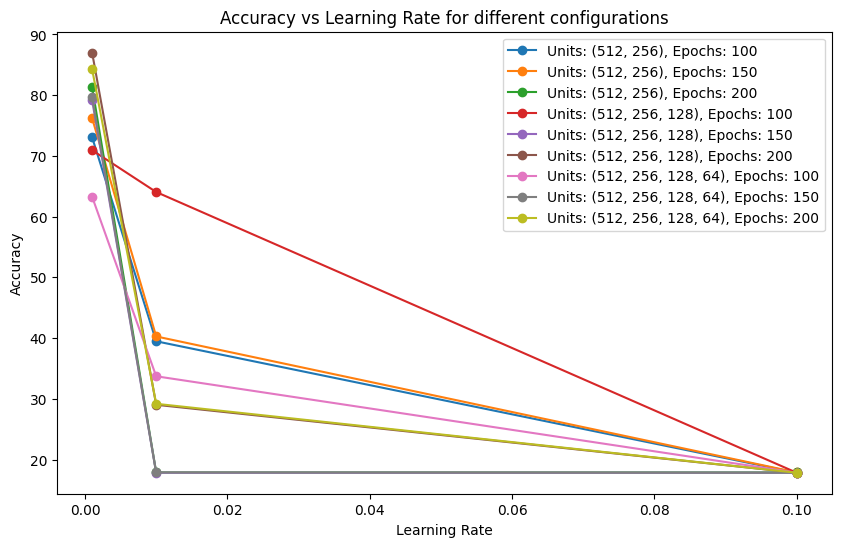

In [37]:
plt.figure(figsize=(10, 6))
for key, grp in df.groupby(['hidden_units_per_layer', 'epochs']):
    plt.plot(grp['learning_rate'], grp['accuracy'], label=f'Units: {key[0]}, Epochs: {key[1]}', marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Learning Rate for different configurations')
plt.legend()
plt.show()

### Convolutional neural network

In [43]:
import itertools
import random
from sklearn.metrics import accuracy_score

batch_sizes = [64, 128, 256]
epochs_list = [10, 20, 30]
optimizers = ['rmsprop', 'adam', 'sgd']
dropout_rates = [0.3, 0.5, 0.7]

n_iter_search = 20
param_combinations = []
for _ in range(n_iter_search):
    params = {
        'batch_size': random.choice(batch_sizes),
        'epochs': random.choice(epochs_list),
        'optimizer': random.choice(optimizers),
        'dropout_rate': random.choice(dropout_rates)
    }
    param_combinations.append(params)

results = []
best_score = 0
best_params = None

for i, params in enumerate(param_combinations):
    print(f"\nIteration {i+1}/{n_iter_search}")
    print(f"Testing params: {params}")

    model = create_model(
        dropout_rate=params['dropout_rate'],
        optimizer=params['optimizer']
    )

    history = model.fit(
        X_train_np, y_train_np,
        batch_size=params['batch_size'],
        epochs=params['epochs'],
        validation_split=0.2,
        verbose=0
    )

    val_accuracy = max(history.history['val_accuracy'])
    print(f"Validation accuracy: {val_accuracy:.4f}")

    results.append({
        'params': params,
        'val_accuracy': val_accuracy
    })

    if val_accuracy > best_score:
        best_score = val_accuracy
        best_params = params

print(f"\nBest parameters: {best_params}")
print(f"Best validation accuracy: {best_score:.4f}")

final_model = create_model(
    dropout_rate=best_params['dropout_rate'],
    optimizer=best_params['optimizer']
)

final_model.fit(
    X_train_np, y_train_np,
    batch_size=best_params['batch_size'],
    epochs=best_params['epochs'],
    validation_split=0.2,
    verbose=1
)

y_pred = final_model.predict(X_test_np)
y_pred_classes = np.argmax(y_pred, axis=1)
test_acc = accuracy_score(y_test_np, y_pred_classes)
print(f"Test accuracy: {test_acc:.4f}")


Iteration 1/20
Testing params: {'batch_size': 128, 'epochs': 10, 'optimizer': 'rmsprop', 'dropout_rate': 0.3}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation accuracy: 0.9465

Iteration 2/20
Testing params: {'batch_size': 256, 'epochs': 10, 'optimizer': 'sgd', 'dropout_rate': 0.7}
Validation accuracy: 0.4531

Iteration 3/20
Testing params: {'batch_size': 256, 'epochs': 10, 'optimizer': 'sgd', 'dropout_rate': 0.5}
Validation accuracy: 0.1740

Iteration 4/20
Testing params: {'batch_size': 64, 'epochs': 10, 'optimizer': 'rmsprop', 'dropout_rate': 0.3}
Validation accuracy: 0.9349

Iteration 5/20
Testing params: {'batch_size': 64, 'epochs': 30, 'optimizer': 'sgd', 'dropout_rate': 0.3}
Validation accuracy: 0.5503

Iteration 6/20
Testing params: {'batch_size': 256, 'epochs': 10, 'optimizer': 'sgd', 'dropout_rate': 0.7}
Validation accuracy: 0.5530

Iteration 7/20
Testing params: {'batch_size': 256, 'epochs': 30, 'optimizer': 'adam', 'dropout_rate': 0.3}
Validation accuracy: 0.9479

Iteration 8/20
Testing params: {'batch_size': 128, 'epochs': 30, 'optimizer': 'adam', 'dropout_rate': 0.3}
Validation accuracy: 0.9672

Iteration 9/20
Testing

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation accuracy: 0.9222

Iteration 11/20
Testing params: {'batch_size': 64, 'epochs': 10, 'optimizer': 'adam', 'dropout_rate': 0.3}
Validation accuracy: 0.9327

Iteration 12/20
Testing params: {'batch_size': 128, 'epochs': 20, 'optimizer': 'sgd', 'dropout_rate': 0.5}
Validation accuracy: 0.7502

Iteration 13/20
Testing params: {'batch_size': 64, 'epochs': 30, 'optimizer': 'adam', 'dropout_rate': 0.7}


...

Validation accuracy: 0.9131

Iteration 15/20
Testing params: {'batch_size': 128, 'epochs': 30, 'optimizer': 'sgd', 'dropout_rate': 0.5}
Validation accuracy: 0.1740

Iteration 16/20
Testing params: {'batch_size': 256, 'epochs': 10, 'optimizer': 'sgd', 'dropout_rate': 0.3}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation accuracy: 0.3673

Iteration 17/20
Testing params: {'batch_size': 64, 'epochs': 30, 'optimizer': 'rmsprop', 'dropout_rate': 0.5}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation accuracy: 0.9505

Iteration 18/20
Testing params: {'batch_size': 64, 'epochs': 10, 'optimizer': 'rmsprop', 'dropout_rate': 0.5}
Validation accuracy: 0.9301

Iteration 19/20
Testing params: {'batch_size': 128, 'epochs': 20, 'optimizer': 'sgd', 'dropout_rate': 0.5}
Validation accuracy: 0.6536

Iteration 20/20
Testing params: {'batch_size': 64, 'epochs': 20, 'optimizer': 'adam', 'dropout_rate': 0.3}
Validation accuracy: 0.9589

Best parameters: {'batch_size': 128, 'epochs': 30, 'optimizer': 'adam', 'dropout_rate': 0.3}
Best validation accuracy: 0.9672
Epoch 1/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4821 - loss: 2.5260 - val_accuracy: 0.7033 - val_loss: 0.8354
Epoch 2/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7233 - loss: 0.7868 - val_accuracy: 0.8078 - val_loss: 0.5538
Epoch 3/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7973 - loss: 0.5876 - val_accuracy: 0.8695 - val_loss: 0.4148
Epoch 4/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/st

## 4. Final models
In this section, please ensure to include cells to train each model with its best hyperparmater combination independently of the hyperparameter tuning cells, i.e. don't rely on the hyperparameter tuning cells having been run.

### Algorithm of choice from first six weeks of course

In [52]:
# Use normalized data (already scaled to [0, 1] in cell b5728c0a)
# Flatten the normalized images to 784-dimensional vectors
X_train_norm_flat = X_train.reshape(X_train.shape[0], -1)
X_test_norm_flat = X_test.reshape(X_test.shape[0], -1)

# Split normalized data using original indices logic (re-using variables from split for consistency)
# Note: y_train_val and y_val were derived from y_train_np02 (which is OrganAMNIST labels)
from sklearn.model_selection import train_test_split
X_train_val_norm, X_val_norm, y_train_val, y_val = train_test_split(
    X_train_norm_flat, y_train, test_size=0.25, random_state=0)

# Combine training and validation normalized data for final training
X_train_combined_norm = np.vstack((X_train_val_norm, X_val_norm))
y_train_combined = np.concatenate((y_train_val, y_val))

print("Training final SVM model on NORMALIZED pixels with best parameters...")
# Retrain SVM on normalized data
final_model_svm = SVC(C=10, gamma='scale', kernel='rbf', random_state=0)
final_model_svm.fit(X_train_combined_norm, y_train_combined)

# Evaluate on normalized test set
test_accuracy_svm = final_model_svm.score(X_test_norm_flat, y_test)
print(f"Final SVM Test Accuracy (Normalized): {test_accuracy_svm:.4f}")

Training final SVM model on NORMALIZED pixels with best parameters...
Final SVM Test Accuracy (Normalized): 0.7810


### Fully connected neural network

In [49]:
# Use the best parameters found during MLP grid search
best_hidden_units_per_layer = [512, 256, 128]
best_lr = 0.001
best_epoch = 200

# Initialize and train the final MLP model
model_mlp = MLP(input_size, best_hidden_units_per_layer, num_classes)
train_losses, test_losses = train(model_mlp, X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor, best_epoch, best_lr)

# Evaluate on test set
model_mlp.eval()
with torch.no_grad():
    mlp_test_outputs = model_mlp(X_test_tensor)
    mlp_test_acc = calculate_accuracy(mlp_test_outputs, y_test_tensor)
print(f"Final MLP Test Accuracy: {mlp_test_acc/100:.4f}")

Epoch 10: Train Loss = 10.715328216552734, Test Loss = 7.68382453918457
Epoch 20: Train Loss = 2.765017509460449, Test Loss = 2.0288891792297363
Epoch 30: Train Loss = 1.611174464225769, Test Loss = 1.8666081428527832
Epoch 40: Train Loss = 1.4008891582489014, Test Loss = 1.527547836303711
Epoch 50: Train Loss = 1.223819375038147, Test Loss = 1.404739260673523
Epoch 60: Train Loss = 1.0874018669128418, Test Loss = 1.2937161922454834
Epoch 70: Train Loss = 0.9811924695968628, Test Loss = 1.2046458721160889
Epoch 80: Train Loss = 0.8969418406486511, Test Loss = 1.1425005197525024
Epoch 90: Train Loss = 0.8311740756034851, Test Loss = 1.0956264734268188
Epoch 100: Train Loss = 0.7747145891189575, Test Loss = 1.0493855476379395
Epoch 110: Train Loss = 0.7313330769538879, Test Loss = 1.0102620124816895
Epoch 120: Train Loss = 0.681062638759613, Test Loss = 1.0009428262710571
Epoch 130: Train Loss = 0.6401070952415466, Test Loss = 0.9690098166465759
Epoch 140: Train Loss = 0.6084660887718201

### Convolutional neural network

In [50]:
# Use the best hyperparameters obtained from the random search
# These were: {'batch_size': 128, 'epochs': 30, 'optimizer': 'adam', 'dropout_rate': 0.3}
final_cnn_params = {
    'batch_size': 128,
    'epochs': 30,
    'optimizer': 'adam',
    'dropout_rate': 0.3
}

print(f"Training final CNN model with params: {final_cnn_params}")

# Create a new model using the best hyperparameters
model_cnn = create_model(dropout_rate=final_cnn_params['dropout_rate'],
                         optimizer=final_cnn_params['optimizer'])

# Train the model on the full training data
history = model_cnn.fit(
    X_train_np, y_train_np,
    epochs=final_cnn_params['epochs'],
    batch_size=final_cnn_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

# Make predictions on the test data
y_pred_cnn = model_cnn.predict(X_test_np)
y_pred_classes = np.argmax(y_pred_cnn, axis=1)

# Calculate and display test accuracy
test_accuracy_cnn = accuracy_score(y_test_np, y_pred_classes)
print(f"\nFinal CNN Test Accuracy: {test_accuracy_cnn:.4f}")

Training final CNN model with params: {'batch_size': 128, 'epochs': 30, 'optimizer': 'adam', 'dropout_rate': 0.3}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4840 - loss: 1.9088 - val_accuracy: 0.6402 - val_loss: 1.0400
Epoch 2/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6879 - loss: 0.9015 - val_accuracy: 0.7975 - val_loss: 0.6365
Epoch 3/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7796 - loss: 0.6493 - val_accuracy: 0.8510 - val_loss: 0.4577
Epoch 4/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8187 - loss: 0.5296 - val_accuracy: 0.8766 - val_loss: 0.3755
Epoch 5/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8393 - loss: 0.4687 - val_accuracy: 0.8846 - val_loss: 0.3452
Epoch 6/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8564 - loss: 0.4170 - val_accuracy: 0.8841 - val_loss: 0.3313
Epoch 7/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8696 - loss: 0.3726 - val_accuracy: 0.9076 - val_loss: 0.2720
Epoch 8/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8871 - loss: 0.3333 - val_accuracy: 0.

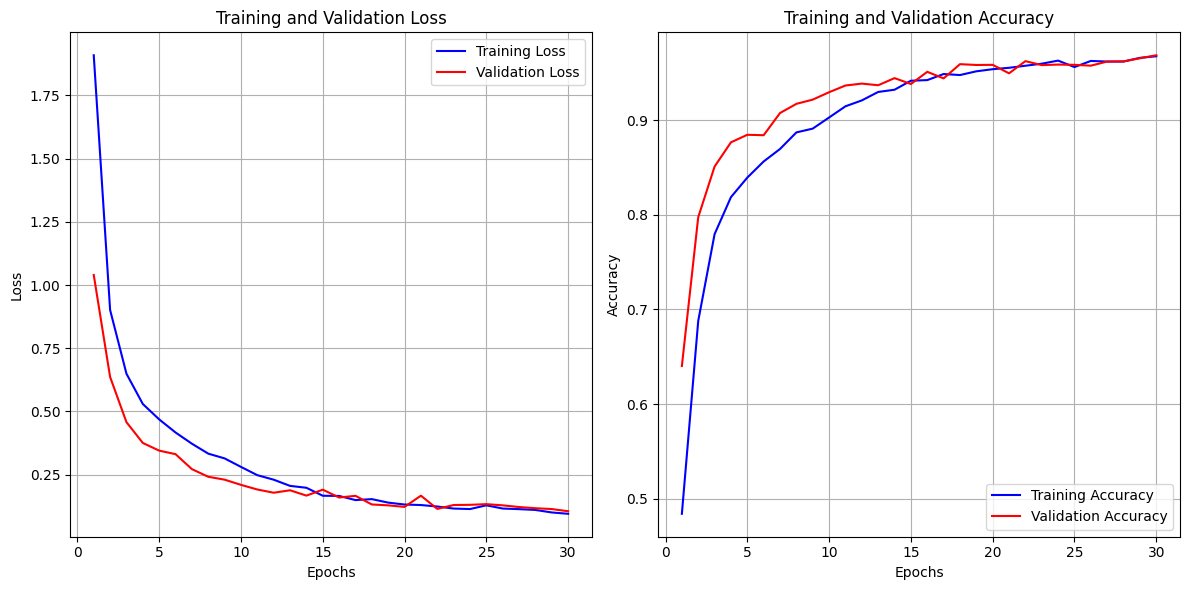

In [51]:
# Extract training and validation loss, training and validation accuracy from the training history
train_loss_np = history.history['loss']
val_loss_np = history.history['val_loss']
train_accuracy_np = history.history['accuracy']
val_accuracy_np = history.history['val_accuracy']
epochs = range(1, len(train_loss_np) + 1)

# Create a figure with two subplots for loss and accuracy
plt.figure(figsize=(12, 6))

# Subplot for training and validation loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_np, 'b-', label='Training Loss')
plt.plot(epochs, val_loss_np, 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()  # Display legend for the curves
plt.grid(True)  # Enable grid lines on the plot

# Subplot for training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy_np, 'b-', label='Training Accuracy')
plt.plot(epochs, val_accuracy_np, 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()  # Display legend for the curves
plt.grid(True)  # Enable grid lines on the plot

# Adjust layout to prevent overlapping of subplots
plt.tight_layout()

# Display the plots
plt.show()
